<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson_9_assignment-9--AK/blob/main/Lesson_9_assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 9: Unsupervised Learning

# 1. Dataset Selection and Preprocessing

Dataset Name: Car Price Prediction Dataset
Source: Kaggle


In [4]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [5]:
# Load dataset
df = pd.read_csv('car_price_data.csv')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())


  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price

In [6]:
# Check Missing Values
print(df.isnull().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [7]:
# Check Duplicate Records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 2


In [8]:
# Remove duplicates
df = df.drop_duplicates()

In [9]:
# Explore Categorical Variables
categorical_columns = df.select_dtypes(include='object')
categorical_columns.head()

for column in categorical_columns.columns:
    print(column)
    print(df[column].unique())
    print("-"*40)

Car_Name
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'He

In [10]:
# One-Hot Encoding convert categorical variables into numerical variables.
df = pd.get_dummies(
    df,
    columns=['Fuel_Type',
             'Seller_Type',
             'Transmission'],
    drop_first=True
)

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Owner  \
0     ritz  2014           3.35           5.59       27000      0   
1      sx4  2013           4.75           9.54       43000      0   
2     ciaz  2017           7.25           9.85        6900      0   
3  wagon r  2011           2.85           4.15        5200      0   
4    swift  2014           4.60           6.87       42450      0   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0             False              True                   False   
1              True             False                   False   
2             False              True                   False   
3             False              True                   False   
4              True             False                   False   

   Transmission_Manual  
0                 True  
1                 True  
2                 True  
3                 True  
4                 True  


In [11]:
# Separate Features and Target

X = df.select_dtypes(include=['number', 'bool']).drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [12]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(X_scaled.head())

       Year  Present_Price  Kms_Driven     Owner  Fuel_Type_Diesel  \
0  0.132992      -0.228097   -0.254603 -0.175101         -0.490575   
1 -0.212787       0.233700    0.156181 -0.175101          2.038424   
2  1.170329       0.269942   -0.770651 -0.175101         -0.490575   
3 -0.904345      -0.396448   -0.814297 -0.175101         -0.490575   
4  0.132992      -0.078451    0.142061 -0.175101          2.038424   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  
0          0.501045               -0.741096             0.387298  
1         -1.995829               -0.741096             0.387298  
2          0.501045               -0.741096             0.387298  
3          0.501045               -0.741096             0.387298  
4         -1.995829               -0.741096             0.387298  


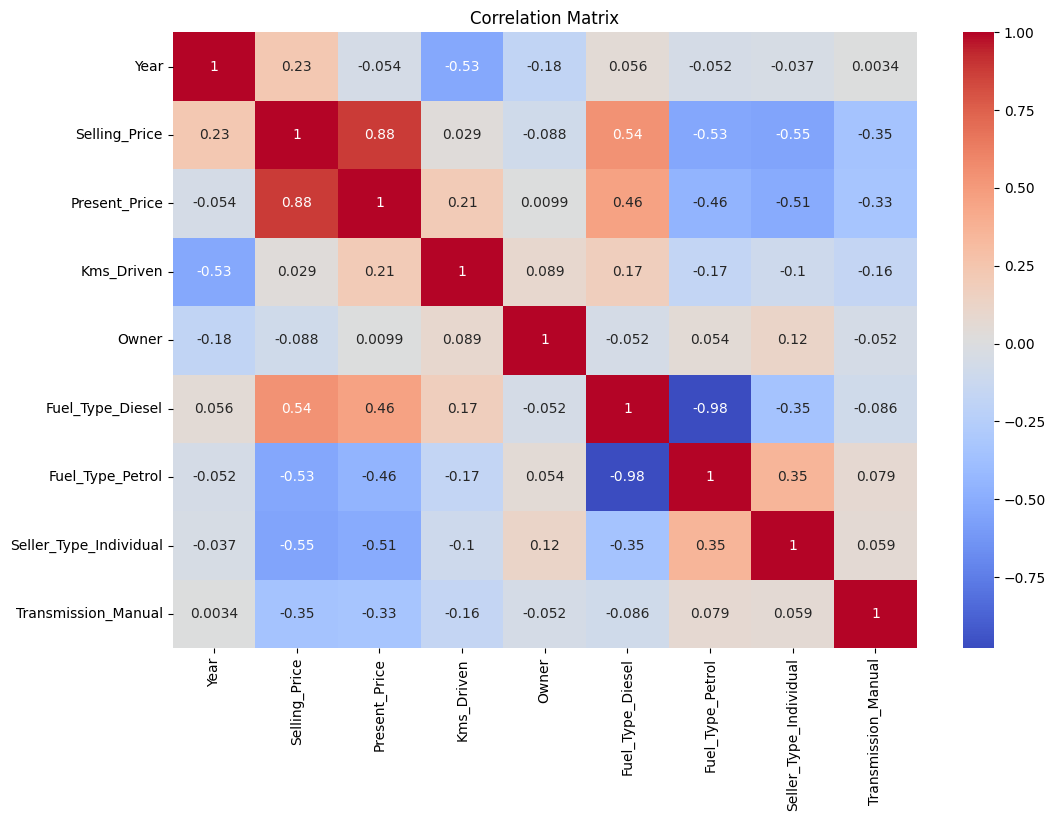

In [17]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

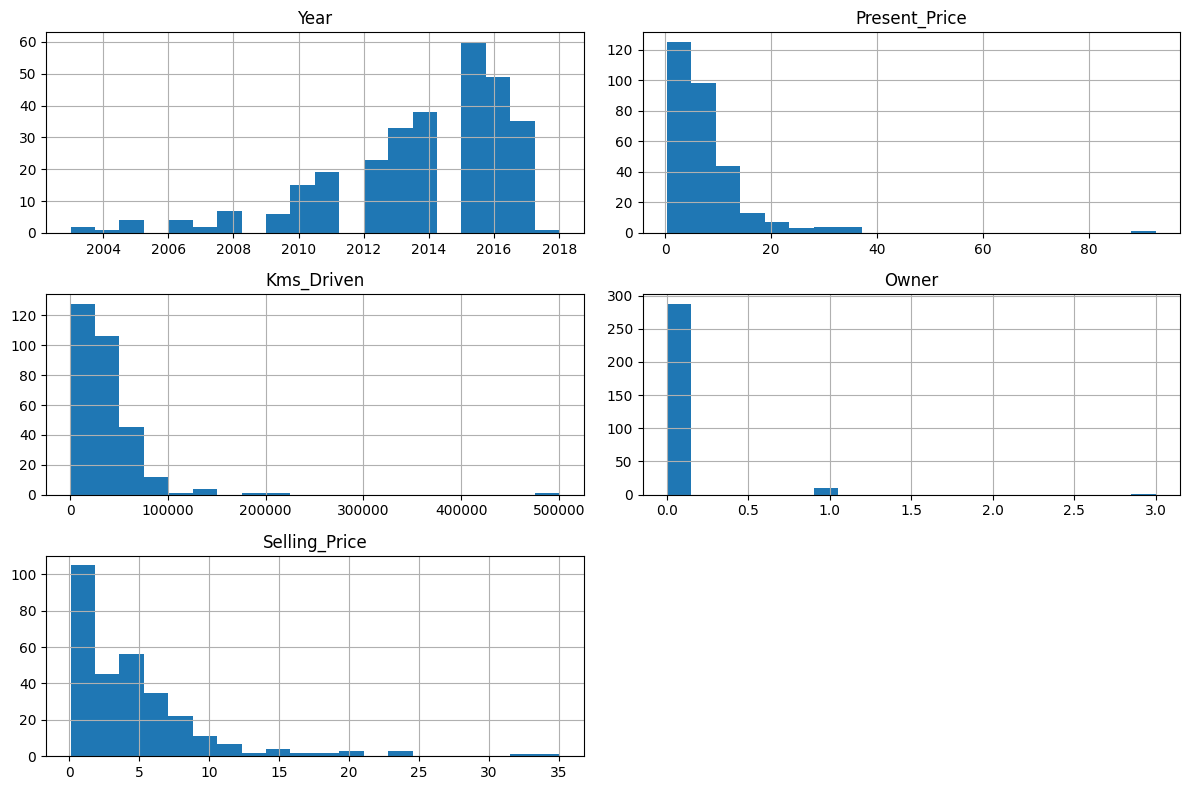

In [13]:
# Distribution of Numerical Features
numerical_columns = ['Year',
                     'Present_Price',
                     'Kms_Driven',
                     'Owner',
                     'Selling_Price']

df[numerical_columns].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

# 2. Clustering Analysis

In [14]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Calculate WCSS for different K values

wcss = []
for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

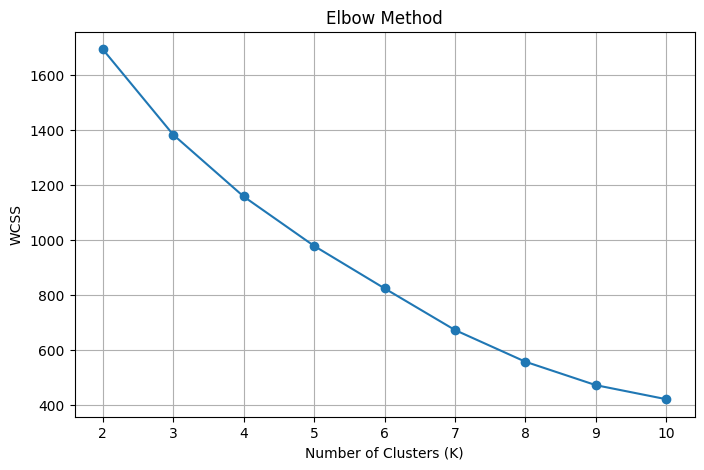

In [16]:
# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()

Interpretation

The elbow curve here shows WCSS dropping quickly at first and then leveling off more gradually, with the elbow appearing around k=4 to K=5, so that range seems to offer a good balance between cluster compactness and simplicity.

In [17]:
silhouette_scores = []

for i in range(2,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

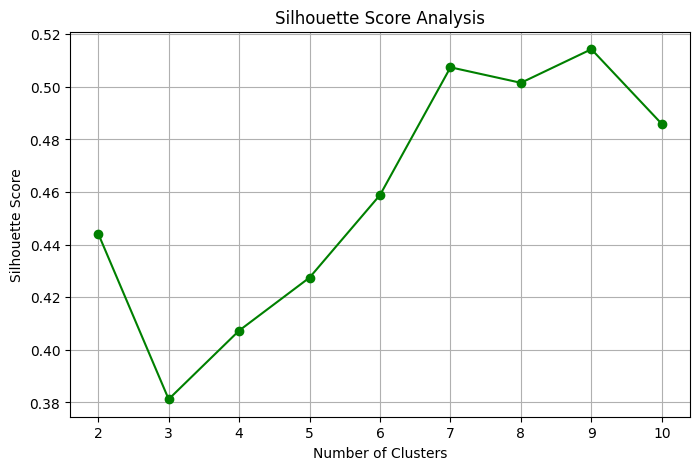

In [18]:
# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2,11),
         silhouette_scores,
         marker='o',
         color='green')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.grid(True)
plt.show()

Interpretation

The silhouette score rises overall with more clusters, reaching its highest values at K = 7–9 (peak ≈ 0.51 at K = 9), which suggests that using around 7–9 clusters yields the most well-separated and cohesive clustering for this dataset.

In [19]:
# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)
X_clustered = X_scaled.copy()
X_clustered["Cluster"] = kmeans_labels

In [21]:
print(X_clustered.head())

       Year  Present_Price  Kms_Driven     Owner  Fuel_Type_Diesel  \
0  0.132992      -0.228097   -0.254603 -0.175101         -0.490575   
1 -0.212787       0.233700    0.156181 -0.175101          2.038424   
2  1.170329       0.269942   -0.770651 -0.175101         -0.490575   
3 -0.904345      -0.396448   -0.814297 -0.175101         -0.490575   
4  0.132992      -0.078451    0.142061 -0.175101          2.038424   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  Cluster  
0          0.501045               -0.741096             0.387298        2  
1         -1.995829               -0.741096             0.387298        1  
2          0.501045               -0.741096             0.387298        2  
3          0.501045               -0.741096             0.387298        2  
4         -1.995829               -0.741096             0.387298        1  


In [22]:
# Cluster Distribution
print(X_clustered["Cluster"].value_counts())

Cluster
2    138
0    103
1     58
Name: count, dtype: int64


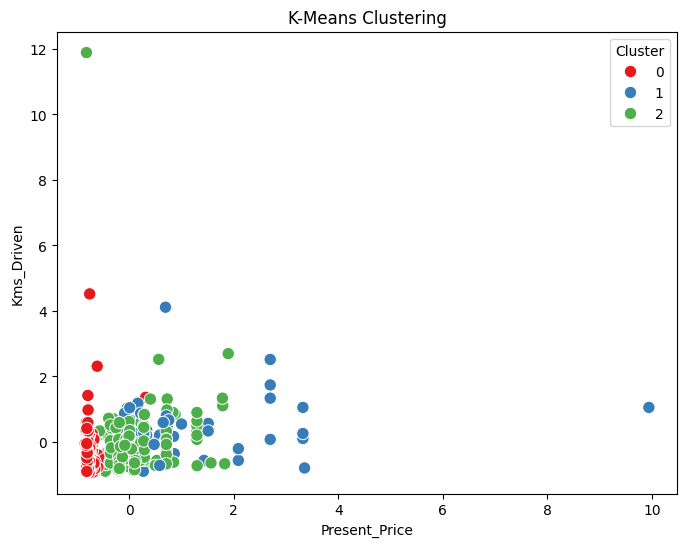

In [23]:
# Visualize K-Means Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_clustered,
    x="Present_Price",
    y="Kms_Driven",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("K-Means Clustering")

plt.show()

Interpretation

The scatter plot shows distinct color-coded clusters in Present_Price vs Kms_Driven space, indicating that K‑means has grouped vehicles with similar prices and mileage into separate, mostly well-separated clusters (with some overlap/outliers).

In [24]:
# Hierarchical Clustering
# Create Linkage Matrix
linked = linkage(
    X_scaled,
    method='ward'
)

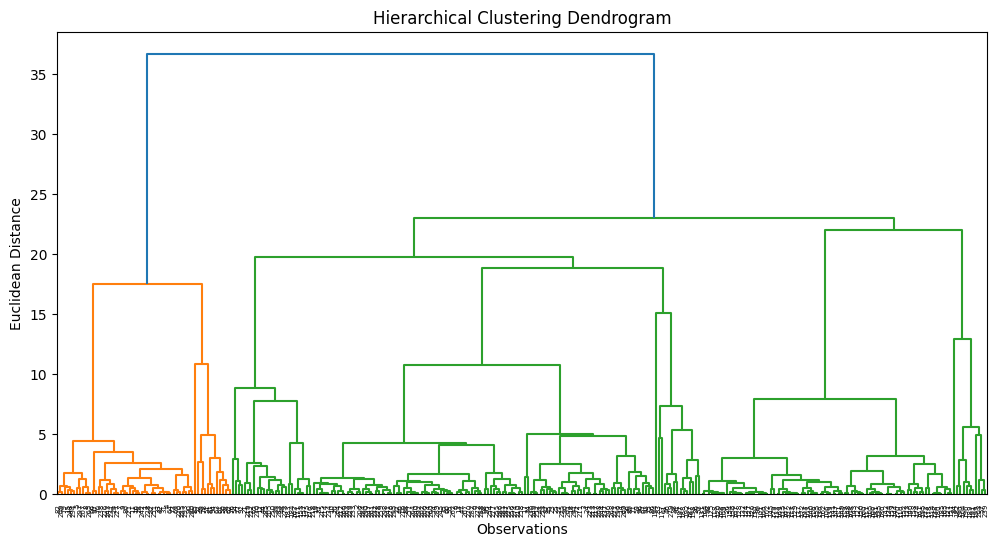

In [25]:
# Plot the Dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Euclidean Distance")

plt.show()

Interpretation

The dendrogram suggests one small, distinct cluster on the left and a larger cluster structure on the right, with a major split occurring at a high distance, indicating that around 2 main clusters may be a reasonable grouping.

In [26]:
# Apply Agglomerative Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=3
)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
X_clustered["Hierarchical_Cluster"] = hierarchical_labels

In [27]:
# Cluster Distribution
print(X_clustered["Hierarchical_Cluster"].value_counts())

Hierarchical_Cluster
2    151
0     92
1     56
Name: count, dtype: int64


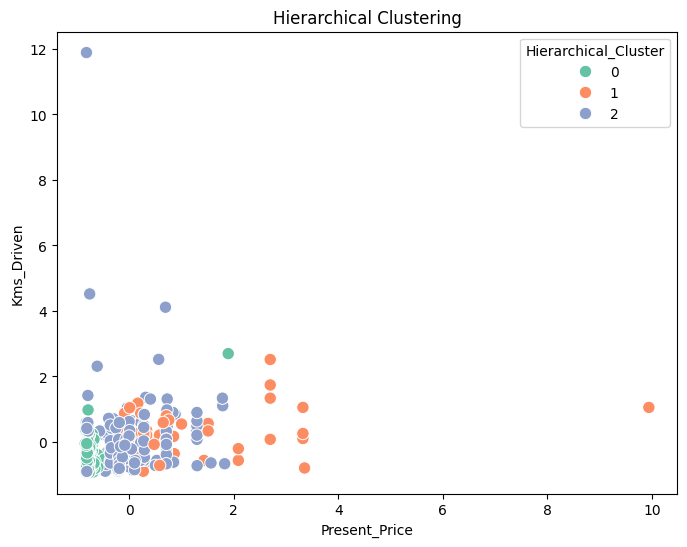

In [28]:
# Visualize Hierarchical Clustering
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=X_clustered,
    x="Present_Price",
    y="Kms_Driven",
    hue="Hierarchical_Cluster",
    palette="Set2",
    s=80
)

plt.title("Hierarchical Clustering")

plt.show()

Interpretation

The scatter plot illustrates three distinct groups derived from hierarchical clustering based on "Kms_Driven" and an unlabeled x-axis metric, showing a highly concentrated cluster 0 at the low end, a moderately spread cluster 2 with a few high-mileage outliers, and a horizontally dispersed cluster 1 extending toward higher x-axis values.

# 3. Dimensionality Reduction

In [29]:
# Import Libraries for Dimensionality Reduction

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [31]:
# Create DataFrame

pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1',
             'Principal Component 2']
)

print(pca_df.head())

   Principal Component 1  Principal Component 2
0              -0.474926               0.323777
1               2.522612               0.531993
2              -0.388954               1.287095
3              -0.635354              -0.018438
4               2.364956               0.787167


In [32]:
# Explained Variance Ratio

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.33939676 0.20059833]


In [33]:
# Total Variance Explained

print("Total Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Total Variance Explained:
0.539995097294763


Interpretation

The chosen principal components capture 54% of the information (variance) present in the original dataset, meaning the remaining 46% of the data's variability has been lost during dimensionality reduction.

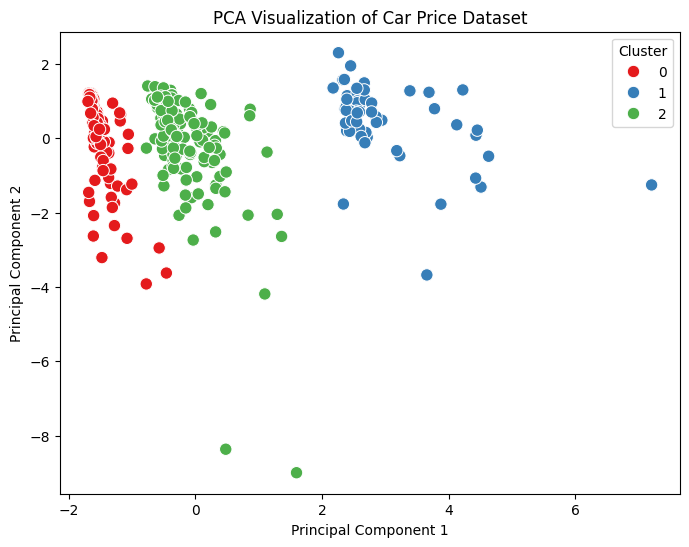

In [34]:
# Visualize PCA

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_df["Principal Component 1"],
    y=pca_df["Principal Component 2"],
    hue=kmeans_labels,
    palette="Set1",
    s=80
)

plt.title("PCA Visualization of Car Price Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

Interpretation

The PCA visualization of the car price dataset demonstrates that the data points are effectively separated along the first principal component into three well-defined, sequentially distributed clusters (0, 2, and 1) representing distinct groupings of car features.

In [36]:
# Apply t-SNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame.
tsne_df = pd.DataFrame(
    X_tsne,
    columns=['t-SNE 1',
             't-SNE 2']
)

print(tsne_df.head())

     t-SNE 1    t-SNE 2
0   5.010307 -11.857649
1  24.252375  11.492947
2  11.771879 -10.589034
3  -0.709970 -11.971941
4  23.936720  12.436982


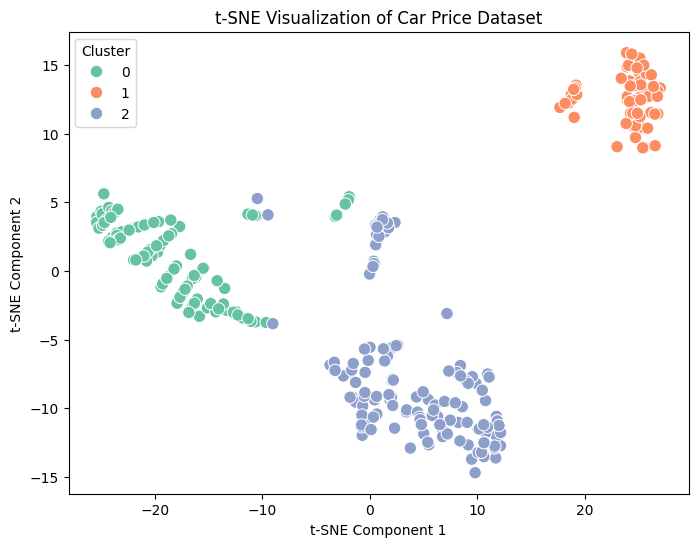

In [37]:
# Visualize t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tsne_df["t-SNE 1"],
    y=tsne_df["t-SNE 2"],
    hue=kmeans_labels,
    palette="Set2",
    s=80
)

plt.title("t-SNE Visualization of Car Price Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster")

plt.show()

Interpretation

The t-SNE visualization reveals that the high-dimensional data has been mapped into three clear, highly distinct clusters, where cluster 1 is completely isolated in the upper right, while cluster 0 and cluster 2 show more intricate, sprawling structures with minimal overlap.

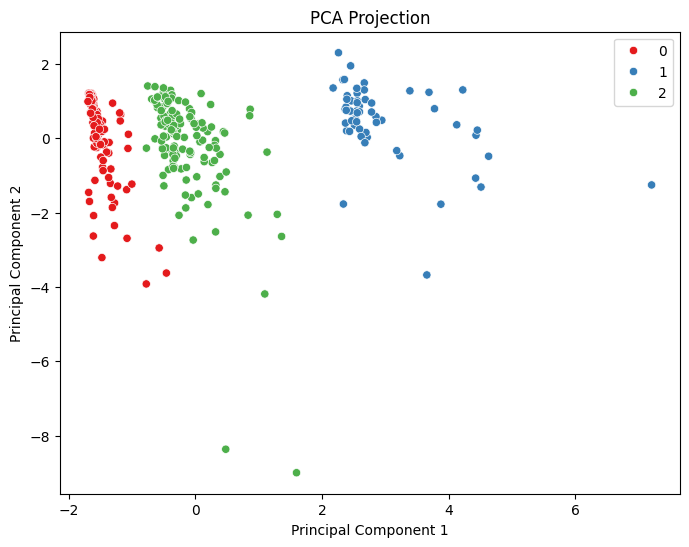

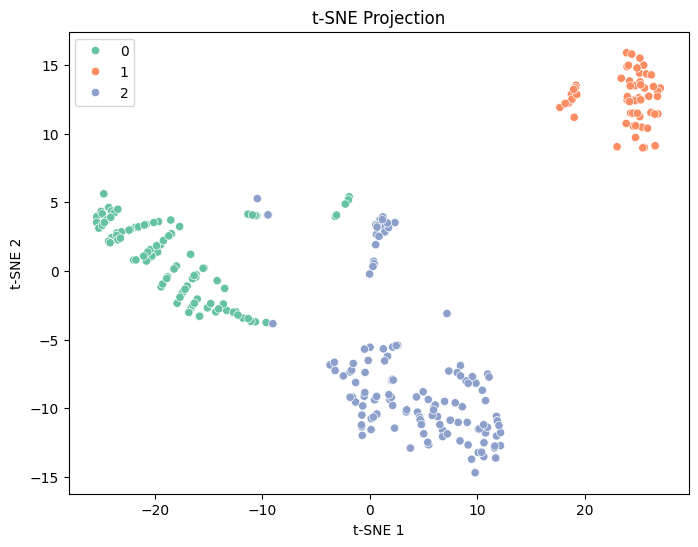

In [38]:
# Plot PCA

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["Principal Component 1"],
    y=pca_df["Principal Component 2"],
    hue=kmeans_labels,
    palette="Set1"
)

plt.title("PCA Projection")

plt.show()

# Plot t-SNE

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=tsne_df["t-SNE 1"],
    y=tsne_df["t-SNE 2"],
    hue=kmeans_labels,
    palette="Set2"
)

plt.title("t-SNE Projection")

plt.show()

# 4. Model Evaluation

In [40]:
# Import Evaluation Metric

from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for K-Means
kmeans_score = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_score, 3))

K-Means Silhouette Score: 0.381


Interpretation

A silhouette score of 0.381 indicates a moderate clustering structure, suggesting that while the data points are generally assigned to the correct clusters, there is significant overlap between clusters or the boundaries between them are not sharply defined.

In [41]:
# Calculate Silhouette Score for Hierarchical Clustering

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Silhouette Score:", round(hierarchical_score, 3))

Hierarchical Silhouette Score: 0.357


Interpretation

A hierarchical silhouette score of 0.357 indicates a relatively weak to moderate clustering structure, meaning the clusters are somewhat overlapping and the data points are not highly distinct or tightly packed within their assigned groups.

In [42]:
# Compare Model Performance
# Create Evaluation Table

evaluation = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical Clustering"],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score
    ]
})

print(evaluation)

                     Model  Silhouette Score
0                  K-Means          0.381236
1  Hierarchical Clustering          0.356604


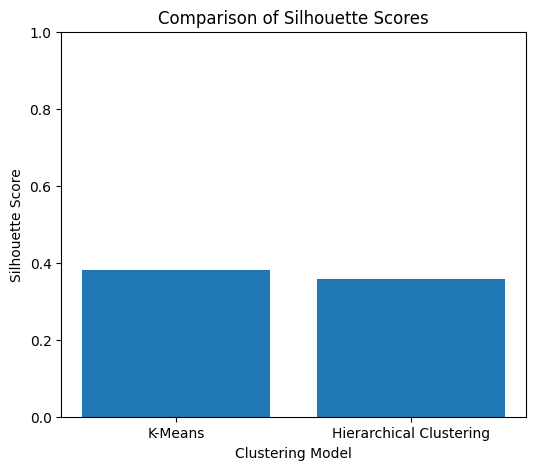

In [43]:
# Visualize Model Performance
plt.figure(figsize=(6,5))

plt.bar(
    evaluation["Model"],
    evaluation["Silhouette Score"]
)

plt.title("Comparison of Silhouette Scores")
plt.xlabel("Clustering Model")
plt.ylabel("Silhouette Score")
plt.ylim(0,1)

plt.show()

In [44]:
# Cluster Size Comparison
pd.Series(kmeans_labels).value_counts().sort_index()

,count
0,103
1,58
2,138


In [45]:
# Hierarchical Clustering
pd.Series(hierarchical_labels).value_counts().sort_index()

,count
0,92
1,56
2,151
